In [1]:
from pathlib import Path
from collections import Counter

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
data_root = Path("D:/Resfes/dataset_binary")

train_dir = data_root / "train"
val_dir   = data_root / "val"
test_dir  = data_root / "test"

print("Train:", train_dir)
print("Val:", val_dir)
print("Test:", test_dir)

Train: D:\Resfes\dataset_binary\train
Val: D:\Resfes\dataset_binary\val
Test: D:\Resfes\dataset_binary\test


In [3]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [4]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(val_dir, transform=eval_transform)
test_dataset  = datasets.ImageFolder(test_dir, transform=eval_transform)

print("Class mapping:", train_dataset.class_to_idx)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

Class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}
Train size: 3650
Val size: 782
Test size: 784


In [5]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size)
test_loader  = DataLoader(test_dataset, batch_size=batch_size)

In [6]:
train_counts = Counter(train_dataset.targets)
val_counts   = Counter(val_dataset.targets)
test_counts  = Counter(test_dataset.targets)

idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}

for name, counts in [("Train", train_counts), ("Val", val_counts), ("Test", test_counts)]:
    print(f"\n{name}:")
    total = sum(counts.values())
    for k, v in counts.items():
        print(f"{idx_to_class[k]}: {v} ({v/total*100:.2f}%)")


Train:
NORMAL: 938 (25.70%)
PNEUMONIA: 2712 (74.30%)

Val:
NORMAL: 201 (25.70%)
PNEUMONIA: 581 (74.30%)

Test:
NORMAL: 202 (25.77%)
PNEUMONIA: 582 (74.23%)


In [7]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Sample labels:", labels[:10])

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Sample labels: tensor([1, 0, 1, 1, 1, 0, 1, 1, 0, 0])


In [8]:
def denormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return img * std + mean

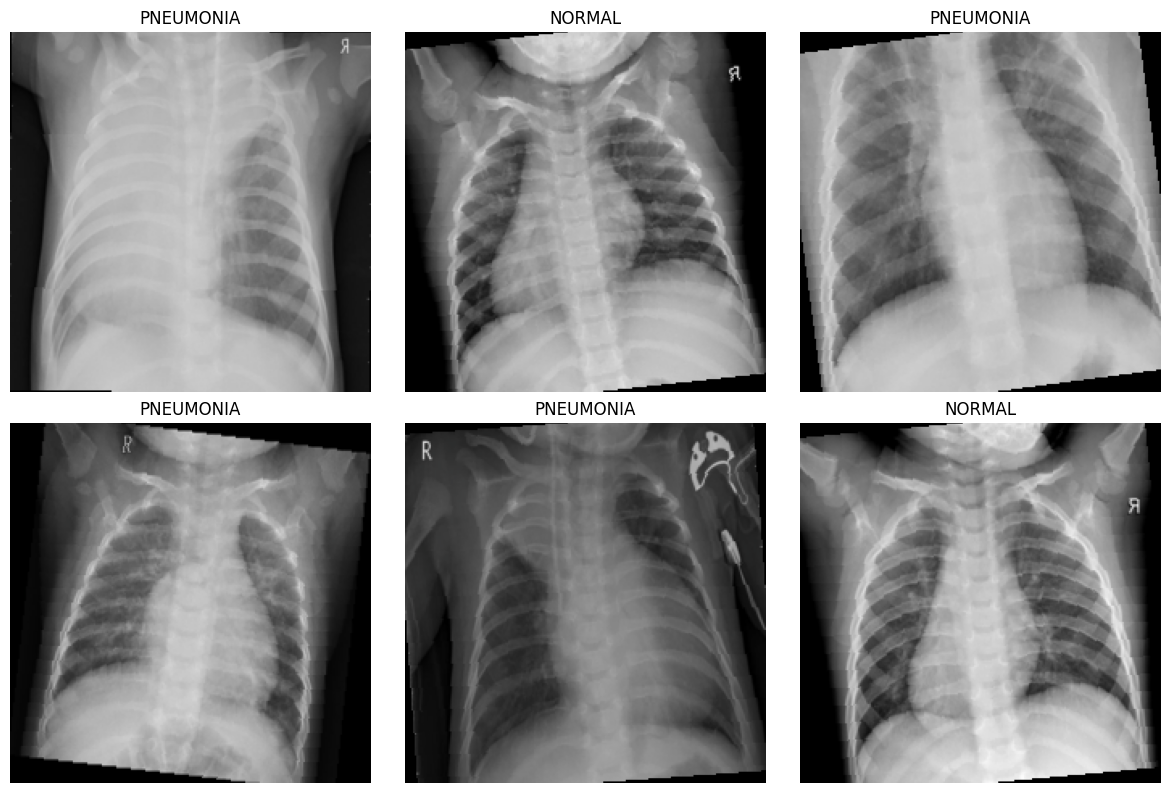

In [9]:
plt.figure(figsize=(12,8))

for i in range(6):
    plt.subplot(2,3,i+1)
    
    img = denormalize(images[i]).permute(1,2,0).numpy()
    img = img.clip(0,1)
    
    label = idx_to_class[labels[i].item()]
    
    plt.imshow(img)
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()

# VISUALIZE DATA

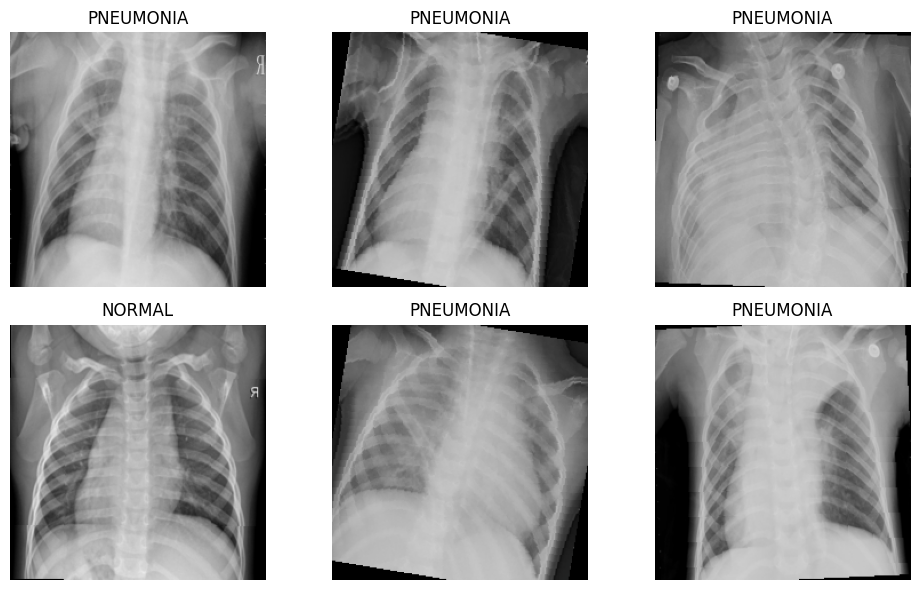

In [15]:
plt.figure(figsize=(10,6))

for i in range(6):
    plt.subplot(2,3,i+1)
    
    img = denormalize(images[i]).permute(1,2,0).numpy()
    img = img.clip(0,1)
    
    label = class_names[labels[i]]
    
    plt.imshow(img)
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()

# KIỂM TRA CLASS IMBALANCE

In [12]:
from collections import Counter
print(Counter(train_dataset.targets))

Counter({1: 2712, 0: 938})


# SHAPE DATA

In [13]:
for images, labels in train_loader:
    print(images.shape)
    break

torch.Size([32, 3, 224, 224])
